In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
df_train = pd.read_csv('Dataset/cleaned_natality2022ps.csv')

In [35]:
df_train.shape

(22969, 43)

In [5]:
df_test = pd.read_csv('Dataset/cleaned_natality2023ps.csv')

In [36]:
df_test.shape

(22414, 43)

In [7]:
df_train = df_train.drop(columns=['dwgt_r', 'ld_ster',
'ld_chor'])

In [8]:
df_test = df_test.drop(columns=['dwgt_r', 'ld_ster',
'ld_chor'])

In [9]:
missing_90_cols = [col for col in df_train.columns if df_train[col].isnull().mean()>0.9]

In [10]:
df_train = df_train.drop(columns=missing_90_cols, errors='ignore')
print("Dropped columns:", missing_90_cols)
print("New shape:", df_train.shape)

Dropped columns: ['mage_impflg', 'mage_repflg', 'mraceimp', 'mar_imp', 'fagerpt_flg', 'compgst_imp', 'obgest_flg', 'lmpused']
New shape: (23011, 75)


In [11]:
df_test = df_test.drop(columns=missing_90_cols, errors='ignore')
print("Dropped columns:", missing_90_cols)
print("New shape:", df_test.shape)

Dropped columns: ['mage_impflg', 'mage_repflg', 'mraceimp', 'mar_imp', 'fagerpt_flg', 'compgst_imp', 'obgest_flg', 'lmpused']
New shape: (22441, 75)


In [12]:
df_train['combgest'] = df_train['combgest'].replace(99, pd.NA)
df_train = df_train.dropna(subset=['combgest']).copy()
print(df_train['combgest'].isnull().sum())

0


In [13]:
df_train['preterm'] = (df_train['combgest']<37).astype(int)

In [14]:
df_train['preterm'].value_counts()

0    19635
1     3334
Name: preterm, dtype: int64

In [34]:
target_leakage_cols = ['combgest', 'gestrec3', 'gestrec10', 'oegest_comb', 'oegest_r10', 'oegest_r3']
df_train = df_train.drop(columns=target_leakage_cols)
df_test = df_test.drop(columns=target_leakage_cols)


In [15]:
df_test['combgest'] = df_test['combgest'].replace(99, pd.NA)
df_test = df_test.dropna(subset=['combgest']).copy()
print(df_test['combgest'].isnull().sum())

0


In [16]:
df_test['preterm'] = (df_test['combgest']<37).astype(int)

In [17]:
df_test['preterm'].value_counts()

0    19184
1     3230
Name: preterm, dtype: int64

In [19]:
unknown_code_map = {
    'mbstate_rec' : 3,'meduc' : 9,'fagecomb' : 99, 'fagerec11': 11, 'frace31': 99,'frace6': 9,'frace15': 99,'feduc': 9,'priorlive': 99,'priordead': 99,
    'priorterm': 99,'lbo_rec' : 9,'tbo_rec': 9,'illb_r': 999,'illb_r11': 99,'ilop_r': 999,
    'ilop_r11': 99,'ilp_r': 999,'ilp_r11': 99,'precare5': 5,'previs_rec': 12, 'cig_0': 99,'cig_1': 99,'cig_2': 99,'cig_3': 99,
    'cig0_r': 6,'cig1_r': 6,'cig2_r': 6,'cig3_r': 6,'m_ht_in': 99,
    'bmi': 99.9,'bmi_r': 9,'pwgt_r': 999,'dwgt_r':999,'wtgain': 99,'wtgain_rec': 9,'rf_cesarn': 99,'no_risks': 9,'no_infec': 9,
    'setorder_r': 9,'dlmp_mm': 99,'dlmp_yy': 9999      
    
}

In [20]:
numeric_cols = df_train.select_dtypes(include=['number']).columns
corr = df_train[numeric_cols].corr()

# Identify highly correlated pairs (threshold >0.9)
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.88:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

corr_pairs


[('mager14', 'mager', 0.9465866699703415),
 ('mager9', 'mager', 0.9715870720034746),
 ('mager9', 'mager14', 0.9703356973396489),
 ('mrace6', 'mrace31', 0.9254156973326154),
 ('mrace15', 'mrace31', 0.8994278680251866),
 ('mrace15', 'mrace6', 0.9653292280455468),
 ('fagerec11', 'fagecomb', 0.9433908012378623),
 ('frace6', 'frace31', 0.9305423171720324),
 ('frace15', 'frace31', 0.9984014116101266),
 ('frace15', 'frace6', 0.9469965861146704),
 ('priordead', 'priorlive', 0.8944364492244197),
 ('illb_r11', 'illb_r', 0.9987079001872541),
 ('ilop_r11', 'ilop_r', 0.9992407431565087),
 ('ilp_r11', 'ilp_r', 0.9989585074241205),
 ('cig_1', 'cig_0', 0.9976922017788977),
 ('cig_2', 'cig_0', 0.9966975558646932),
 ('cig_2', 'cig_1', 0.998661338393372),
 ('cig_3', 'cig_0', 0.9294611311320045),
 ('cig_3', 'cig_1', 0.9312705590333874),
 ('cig_3', 'cig_2', 0.9310994742928387),
 ('cig0_r', 'cig_0', 0.9937237905034975),
 ('cig0_r', 'cig_1', 0.988053031970052),
 ('cig0_r', 'cig_2', 0.985884999594741),
 ('cig

In [22]:
cols_to_drop = ['mager14', 'mager9', 'mrace31', 'mrace15', 'frace31', 'frace15',
                'lbo_rec', 'wtgain_rec', 'ilp_r11', 'ilop_r11', 'illb_r11', 'bmi_r', 'pwgt_r', 'fagerec11',
                'cig_3', 'cig_1', 'cig_0', 'cig_2']



In [23]:
df_train = df_train.drop(columns=cols_to_drop)
print(df_train.shape)


(22969, 58)


In [24]:
df_test = df_test.drop(columns=cols_to_drop)
print(df_test.shape)

(22414, 58)


In [28]:
df_train = df_train.drop(columns=['dlmp_yy', 'dlmp_mm', 'wic', 'previs', 'precare', 'mbstate_rec'])
df_test = df_test.drop(columns=['dlmp_yy', 'dlmp_mm', 'wic', 'previs', 'precare', 'mbstate_rec'])

In [29]:
df_train = df_train.drop(columns=['no_risks', 'no_infec', 'cig_rec'])
df_test = df_test.drop(columns=['no_risks', 'no_infec', 'cig_rec'])

KeyError: "['no_risks' 'no_infec' 'cig_rec'] not found in axis"

In [30]:
df_train.shape

(22969, 49)

In [31]:
df_test.shape

(22414, 49)

In [37]:
X_train = df_train.drop(columns=['preterm'])
y_train = df_train['preterm']
X_test = df_test.drop(columns=['preterm'])
y_test = df_test['preterm']

In [41]:

preterm_pregnancy_train = df_train['preterm'].value_counts().reset_index()
preterm_pregnancy_test = df_test['preterm'].value_counts().reset_index()

print ('preterm_pregnancy_train: \n ',preterm_pregnancy_train)
print ('test: \n ',preterm_pregnancy_test)
     

preterm_pregnancy_train: 
     index  preterm
0      0    19635
1      1     3334
test: 
     index  preterm
0      0    19184
1      1     3230


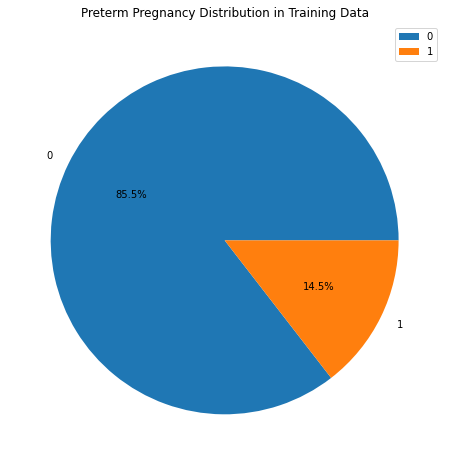

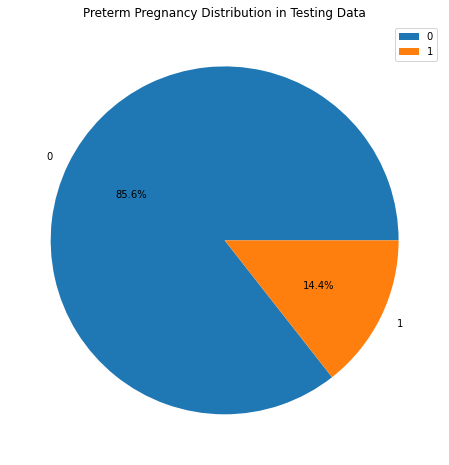

In [42]:

plt.figure(figsize =(12,8))
plt.pie(preterm_pregnancy_train['preterm'],labels =preterm_pregnancy_train['index'],autopct="%.1f%%")
plt.legend()
plt.title('Preterm Pregnancy Distribution in Training Data')
plt.show()


plt.figure(figsize =(12,8))
plt.pie(preterm_pregnancy_test['preterm'],labels =preterm_pregnancy_test['index'],autopct="%.1f%%")
plt.legend()
plt.title('Preterm Pregnancy Distribution in Testing Data')
plt.show()

In [43]:
numeric_continuous_features = ['mager', 'fagecomb',
       'priorlive', 'priordead', 'priorterm', 'illb_r', 'ilop_r',
       'ilp_r', 'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn']
len(numeric_continuous_features)

12

In [44]:
unknown_code_map = {
    'fagecomb' : 99, 'priorlive': 99,'priordead': 99,'priorterm': 99,'illb_r': 999,'ilop_r': 999,'ilp_r': 999,'m_ht_in': 99,
    'bmi': 99.9,'wtgain': 99,'rf_cesarn': 99
}
len(unknown_code_map)

11

In [45]:
unknown_code_map.items()

dict_items([('fagecomb', 99), ('priorlive', 99), ('priordead', 99), ('priorterm', 99), ('illb_r', 999), ('ilop_r', 999), ('ilp_r', 999), ('m_ht_in', 99), ('bmi', 99.9), ('wtgain', 99), ('rf_cesarn', 99)])

In [47]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in df_train.columns:
        X_train[col] = X_train[col].replace(code, pd.NA)

In [50]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in df_test.columns:
        X_test[col] = X_test[col].replace(code, pd.NA)

In [48]:
ordinal_features = ['meduc', 'feduc',  'cig0_r', 'cig1_r', 'cig2_r',
       'cig3_r',  'precare5', 'previs_rec',  'dplural', 'tbo_rec']
len(ordinal_features)

10

In [49]:

all_features = X_train.columns.tolist()
one_hot_features = list(set(all_features) - set(numeric_continuous_features) - set(ordinal_features))
print(one_hot_features)
len(one_hot_features)

['rf_ehype', 'frace6', 'rf_ghype', 'rf_fedrg', 'rf_ppterm', 'setorder_r', 'rf_pdiab', 'ip_gon', 'rf_artec', 'rf_gdiab', 'ip_chlam', 'mar_p', 'rf_phype', 'ip_hepb', 'mrace6', 'rf_cesar', 'rf_inftr', 'dmar', 'ip_syph', 'ip_hepc']


20

In [51]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [52]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = 'passthrough'

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

In [54]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_pipeline, numeric_continuous_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('onehot', categorical_pipeline, one_hot_features)
    ]
)

In [55]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [64]:

from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
sclr = scaler.fit(X_train_processed)
X_train_processed = sclr.transform(X_train_processed)
X_test_processed = sclr.transform(X_test_processed)

In [65]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [66]:
y_pred = clf.predict(X_test_processed)

In [67]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     19184
           1       0.67      0.17      0.27      3230

    accuracy                           0.87     22414
   macro avg       0.77      0.58      0.60     22414
weighted avg       0.85      0.87      0.83     22414



In [68]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[18913   271]
 [ 2683   547]]


In [69]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [70]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=[0,1], y=y_train)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, class_weight=class_weights_dict)

rf_random = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_dist,
    n_iter = 30,
    scoring = 'f1',
    cv = 4,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

rf_random.fit(X_train_processed, y_train)

print("Best parameters:", rf_random.best_params_)


Fitting 4 folds for each of 30 candidates, totalling 120 fits


In [74]:
best_model = rf_random.best_estimator_
y_pred_best = best_model.predict(X_test_processed)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

[[14422  4762]
 [ 1214  2016]]
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     19184
           1       0.30      0.62      0.40      3230

    accuracy                           0.73     22414
   macro avg       0.61      0.69      0.62     22414
weighted avg       0.83      0.73      0.77     22414

